# 8 · Generalizace na neznámé dodavatele (DS3)

**Odpovídá sekcím 5.2–5.5 práce** — *Generalizace na syntetické sadě DS3,
Typizace chyb, Diskuse a limity* (Tabulka 5.3, Obrázek 5.7).

Výsledky na DS1 mohou být nadhodnocené tím, že systém dodavatele „zná“ — jejich
šablony se opakují napříč vývojem i evaluací. Notebook proto ověřuje řešení na
sadě **DS3: 162 syntetických faktur od 18 fiktivních dodavatelů**.

Syntetická data zaručují čistý zero-shot test absolutně: žádný z fiktivních
dodavatelů se nevyskytuje v trénovacích datech žádného testovaného modelu.

**Otázka:** Jsou výsledky z DS1 vázané na známé dodavatele, nebo řešení skutečně
generalizuje?

## O datové sadě DS3

| | |
|---|---|
| **Rozsah** | 162 faktur, 18 fiktivních dodavatelů (3 na každou z 6 komodit) |
| **Vznik** | programově generovaná PDF (knihovna `reportlab`) |
| **Vizuální styly** | minimalistický, strukturovaný, dopisový |
| **Degradace** | 9 faktur na dodavatele, rovnoměrně Q1 / Q2 / Q3 |
| **Ground truth** | generováno souběžně s fakturou → 100 % přesné |

Generovací skript je součástí repozitáře: `scripts/generate_synthetic_invoices.py`.
Samotné faktury jsou v `data/ds3/` — na rozdíl od reálných sad je lze zveřejnit.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

KOREN = Path.cwd().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(KOREN / "experiments"))

from thesis_style import *          # noqa: F403
pouzij_styl()

DATA = KOREN / "experiments" / "data"
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
print("Data:", DATA.relative_to(KOREN))

Data: experiments\data


In [2]:
ds3 = pd.read_csv(DATA / "08_generalizace_ds3" / "ds3_per_invoice.csv")
ds3_pole = pd.read_csv(DATA / "08_generalizace_ds3" / "ds3_per_field.csv")
ds3_pole = ds3_pole.merge(ds3[["doc_idx", "commodity", "quality"]], on="doc_idx")

ds1 = pd.read_csv(DATA / "07_evaluace_ds1" / "ds1_per_invoice.csv")
ds1_pole = pd.read_csv(DATA / "07_evaluace_ds1" / "ds1_per_field.csv")

presnost_ds3 = ds3_pole.groupby("field").status.apply(lambda s: (s == "tp").mean())
presnost_ds1 = ds1_pole.groupby("field").status.apply(lambda s: (s == "tp").mean())

print(f"DS3 : {len(ds3)} faktur, {ds3.commodity.nunique()} komodit")
print(f"DS1 : {len(ds1)} faktur (pro srovnání)")

DS3 : 162 faktur, 6 komodit
DS1 : 573 faktur (pro srovnání)


## 8.1 Celkové výsledky (Tabulka 5.3 v práci)

In [3]:
souhrn = pd.DataFrame({
    "Ukazatel": ["F1 skóre (průměr přes komodity)", "Přesnost (Precision)",
                 "Úplnost (Recall)", "Podíl dokumentů na záložní cestě",
                 "Cena na dokument", "Průměrná doba zpracování"],
    "DS3 (noví dodavatelé)": [
        f"{ds3.f1.mean():.3f}", f"{ds3.precision.mean():.3f}", f"{ds3.recall.mean():.3f}",
        f"{int(ds3.escalated.sum())} / {len(ds3)} ({ds3.escalated.mean():.1%})",
        f"${ds3.cost_usd.mean():.3f} (~ {ds3.cost_usd.mean() * 23.5:.2f} Kč)",
        f"{ds3.full_pipeline_ms.mean() / 1000:.1f} s"],
    "DS1 (reálné faktury)": [
        f"{ds1.f1.mean():.3f}", f"{ds1.precision.mean():.3f}", f"{ds1.recall.mean():.3f}",
        f"{int(ds1.escalated.sum())} / {len(ds1)} ({ds1.escalated.mean():.1%})",
        f"${ds1.cost_usd.mean():.3f} (~ {ds1.cost_usd.mean() * 23.5:.2f} Kč)",
        f"{ds1.full_pipeline_ms.mean() / 1000:.1f} s"],
}).set_index("Ukazatel")
display(souhrn.style.set_properties(subset=["DS3 (noví dodavatelé)"],
                                    **{"font-weight": "600"}))

,DS3 (noví dodavatelé),DS1 (reálné faktury)
Ukazatel,,
F1 skóre (průměr přes komodity),0.938,0.847
Přesnost (Precision),0.946,0.810
Úplnost (Recall),0.940,0.906
Podíl dokumentů na záložní cestě,104 / 162 (64.2%),88 / 573 (15.4%)
Cena na dokument,$0.026 (~ 0.61 Kč),$0.030 (~ 0.71 Kč)
Průměrná doba zpracování,18.9 s,18.4 s


> **Zjištění.** Celkové F1 skóre je na DS3 dokonce **vyšší** než na DS1
> (0,938 oproti 0,847). Nápadný je ale mnohem vyšší podíl dokumentů odeslaných na
> záložní cestu — **64,2 % oproti 15,4 %**.
>
> Důvodem je akceptační kontrola: ta vyžaduje úspěšné přiřazení dodavatele vůči
> referenční databázi (notebook `06`), a u dosud neznámých dodavatelů toto
> přiřazení často selže. Dokument tak postoupí na záložní cestu, i když by jinak
> hlavní cesta obstála.

## 8.2 Splnění kritérií na neznámých dodavatelích

Kritérium K5 (částka s DPH) se na DS3 nevyhodnocuje — syntetické faktury toto pole
v porovnatelné podobě neobsahují. Hodnotí se tedy 8 kritérií místo devíti.

In [4]:
def kriteria_sady(faktury, presnost_pole, s_k5=True):
    def presnost(nazev):
        return presnost_pole.get(nazev, float("nan"))
    polozky = [
        ("K1", "F1 (průměr přes komodity) ≥ 0,60", 0.60,
         faktury.groupby("commodity").f1.mean().mean()),
        ("K2", "invoice_number ≥ 85 %",   0.85, presnost("invoice_number")),
        ("K3", "supplier_tax_id ≥ 85 %",  0.85, presnost("supplier_tax_id")),
        ("K4", "customer_tax_id ≥ 85 %",  0.85, presnost("customer_tax_id")),
    ]
    if s_k5:
        polozky.append(("K5", "amount_inc_vat ≥ 85 %", 0.85, presnost("amount_inc_vat")))
    polozky += [
        ("K6", "due_date ≥ 85 %",         0.85, presnost("due_date")),
        ("K7", "JSON Validity ≥ 98 %",    0.98, faktury.json_valid.mean()),
        ("K8", "Latence ≤ 60 s",          60.0, faktury.full_pipeline_ms.mean() / 1000),
        ("K9", "F1 nejhorší třídy ≥ 0,45", 0.45, faktury.groupby("quality").f1.mean().min()),
    ]
    radky = []
    for kod, podminka, prah, hodnota in polozky:
        splneno = hodnota <= prah if kod == "K8" else hodnota >= prah
        radky.append({"Krit.": kod, "Podmínka": podminka,
                      "Dosaženo": f"{hodnota:.1f} s" if kod == "K8" else f"{hodnota:.1%}",
                      "Splněno": "ano" if splneno else "NE"})
    return pd.DataFrame(radky).set_index("Krit.")

tab3 = kriteria_sady(ds3, presnost_ds3, s_k5=False)
print(f"DS3: splněno {(tab3['Splněno'] == 'ano').sum()} z {len(tab3)} kritérií.")
display(tab3.style.apply(
    lambda r: ["background-color:#FDEDEC;font-weight:700" if r["Splněno"] == "NE"
               else "" for _ in r], axis=1))

DS3: splněno 6 z 8 kritérií.


,Podmínka,Dosaženo,Splněno
Krit.,,,
K1,"F1 (průměr přes komodity) ≥ 0,60",93.8%,ano
K2,invoice_number ≥ 85 %,82.1%,NE
K3,supplier_tax_id ≥ 85 %,93.3%,ano
K4,customer_tax_id ≥ 85 %,71.1%,NE
K6,due_date ≥ 85 %,90.7%,ano
K7,JSON Validity ≥ 98 %,100.0%,ano
K8,Latence ≤ 60 s,18.9 s,ano
K9,"F1 nejhorší třídy ≥ 0,45",88.0%,ano


> **Zjištění.** Na DS3 neprošla **jiná dvě kritéria** než na DS1: číslo faktury
> a IČO odběratele zde nahradily částku s DPH a datum splatnosti. To dokazuje, že
> narážíme na odlišný, doplňkový typ chyby, nikoli na prohloubení původního problému.

## 8.3 Srovnání společných polí DS1 vs. DS3 (Obrázek 5.7 v práci)

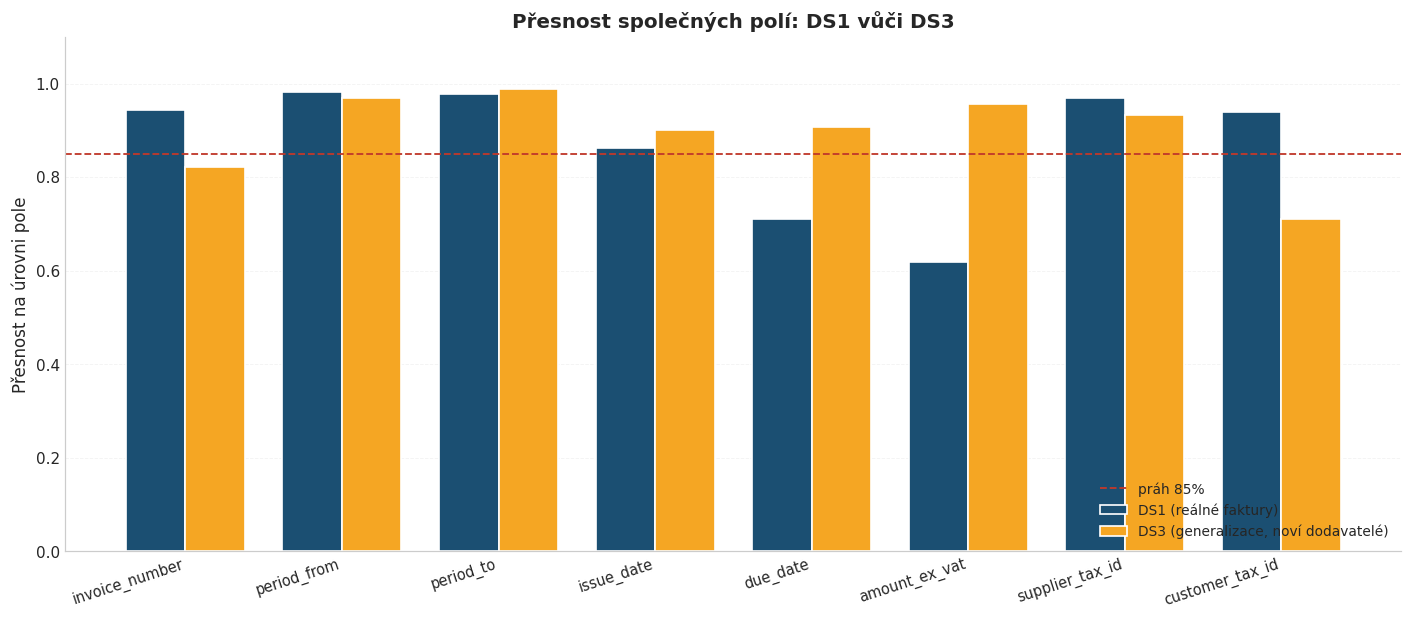

,DS1 (reálné faktury),DS3 (noví dodavatelé),rozdíl
field,,,
amount_ex_vat,0.618,0.956,0.337
due_date,0.710,0.907,0.197
issue_date,0.863,0.901,0.038
period_to,0.977,0.988,0.011
period_from,0.982,0.969,-0.013
supplier_tax_id,0.969,0.933,-0.036
invoice_number,0.944,0.821,-0.123
customer_tax_id,0.938,0.711,-0.227


In [5]:
SPOLECNA = ["invoice_number", "period_from", "period_to", "issue_date",
            "due_date", "amount_ex_vat", "supplier_tax_id", "customer_tax_id"]
PRAH_POLE = 0.85

srovnani = pd.DataFrame({
    "DS1 (reálné faktury)": presnost_ds1.reindex(SPOLECNA),
    "DS3 (noví dodavatelé)": presnost_ds3.reindex(SPOLECNA),
})
srovnani["rozdíl"] = srovnani["DS3 (noví dodavatelé)"] - srovnani["DS1 (reálné faktury)"]

fig, ax = plt.subplots(figsize=(13, 5.8))
x, sirka = np.arange(len(SPOLECNA)), 0.38
ax.bar(x - sirka / 2, srovnani["DS1 (reálné faktury)"], sirka,
       label="DS1 (reálné faktury)", color="#1B4F72", edgecolor="white", linewidth=1.1)
ax.bar(x + sirka / 2, srovnani["DS3 (noví dodavatelé)"], sirka,
       label="DS3 (generalizace, noví dodavatelé)", color="#F5A623",
       edgecolor="white", linewidth=1.1)
ax.axhline(PRAH_POLE, color=PRAH, linestyle="--", linewidth=1.2,
           label=f"práh {PRAH_POLE:.0%}")
ax.set_xticks(x)
ax.set_xticklabels(SPOLECNA, rotation=18, ha="right", fontsize=9.5)
ax.set_ylim(0, 1.1)
uprav_osu(ax, "Přesnost společných polí: DS1 vůči DS3", y="Přesnost na úrovni pole")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

display(tabulka(srovnani.sort_values("rozdíl", ascending=False).round(4)))

> **Zjištění.** Srovnání ukazuje rozdělení do dvou odlišných skupin:
>
> * **Pole vázaná na obsah, ne na formát dodavatele** — datum splatnosti (0,71 → 0,91),
>   částka bez DPH (0,62 → 0,96), datum vystavení a fakturační období — vykazují
>   dobrou schopnost zobecnění a jejich úspěšnost se dokonce **zvyšuje**.
> * **Identifikační pole, jejichž zápis se mezi dodavateli výrazně liší** — číslo
>   faktury (0,94 → 0,82) a IČO odběratele (0,94 → 0,71) — na datech nových
>   dodavatelů **klesají**. Na rozdíl od data nebo částky nemá číslo faktury ani
>   IČO jednotný formát; model se jejich zápis učí spíš z konkrétních příkladů než
>   obecně, a u nových dodavatelů tak nemá co napodobit.

## 8.4 Stabilita napříč komoditami a kvalitou

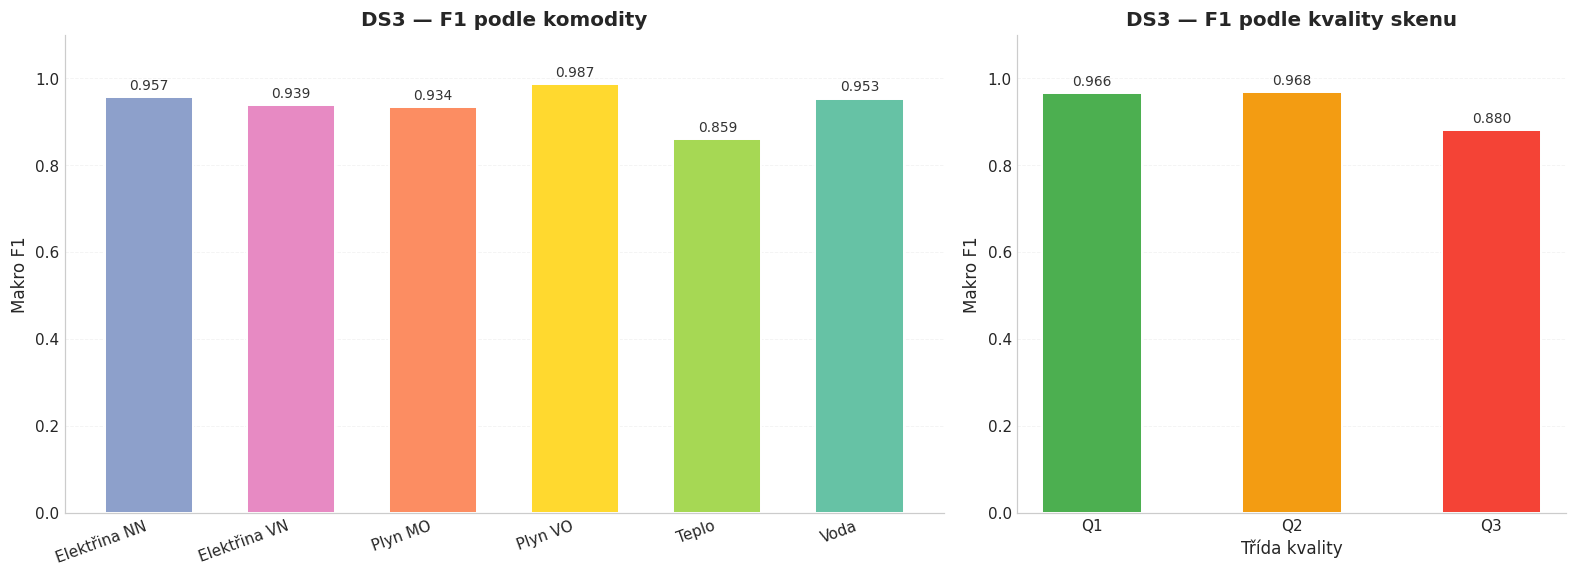

Rozpětí napříč komoditami : 0.859 – 0.987
Rozpětí napříč kvalitou   : 0.880 – 0.968


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.5, 5.4),
                               gridspec_kw={"width_ratios": [1.6, 1]})

k3 = ds3.groupby("commodity").f1.mean().reindex(KOMODITY)
ax1.bar([NAZVY_KOMODIT[k] for k in k3.index], k3,
        color=[BARVY_KOMODIT[k] for k in k3.index], width=0.62,
        edgecolor="white", linewidth=1.3)
popisky_sloupcu(ax1, fmt="{:.3f}")
ax1.set_ylim(0, 1.1)
uprav_osu(ax1, "DS3 — F1 podle komodity", y="Makro F1")
ax1.tick_params(axis="x", rotation=20)
for p in ax1.get_xticklabels():
    p.set_ha("right")
ax1.grid(axis="x", visible=False)

q3 = ds3.groupby("quality").f1.mean()
BARVY_TRID = {"Q1": "#4CAF50", "Q2": "#F39C12", "Q3": "#F44336"}
ax2.bar(q3.index, q3, color=[BARVY_TRID[q] for q in q3.index], width=0.5,
        edgecolor="white", linewidth=1.3)
popisky_sloupcu(ax2, fmt="{:.3f}")
ax2.set_ylim(0, 1.1)
uprav_osu(ax2, "DS3 — F1 podle kvality skenu", x="Třída kvality", y="Makro F1")
ax2.grid(axis="x", visible=False)

fig.tight_layout()
plt.show()

print(f"Rozpětí napříč komoditami : {k3.min():.3f} – {k3.max():.3f}")
print(f"Rozpětí napříč kvalitou   : {q3.min():.3f} – {q3.max():.3f}")

> **Zjištění.** Celkové výsledky na DS3 zůstávají stabilně vysoké a nevykazují
> žádné výrazně slabé místo — ani napříč komoditami, ani napříč třídami kvality.

## 8.5 Typizace chyb (sekce 5.4 v práci)

Chyby popsané v notebooku `07` i zde se dají roztřídit do tří skupin **podle
příčiny**, ne podle konkrétního pole.

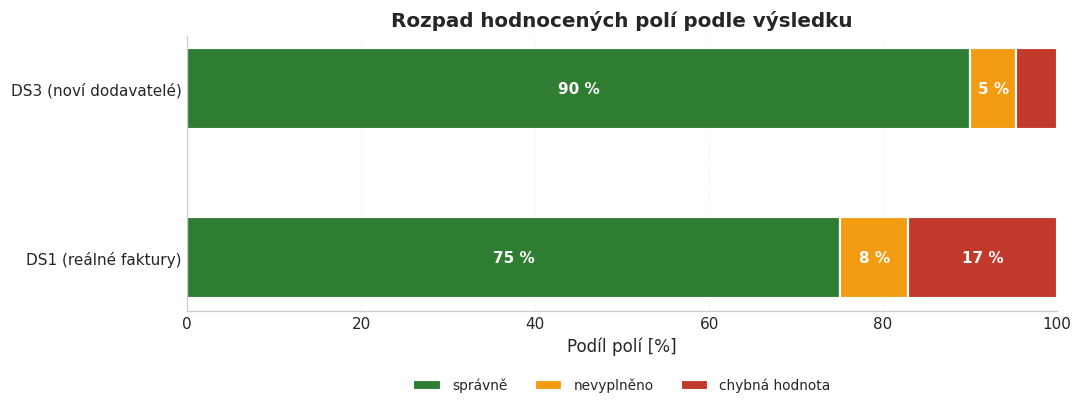

In [7]:
def rozpad_stavu(pole_df, popis):
    r = pole_df.groupby("status").size()
    return pd.Series({"správně": r.get("tp", 0),
                      "nevyplněno": r.get("fn", 0),
                      "chybná hodnota": r.get("fp", 0)}, name=popis)

rozpad = pd.DataFrame([
    rozpad_stavu(ds1_pole, "DS1 (reálné faktury)"),
    rozpad_stavu(ds3_pole, "DS3 (noví dodavatelé)"),
])
rozpad_pct = rozpad.div(rozpad.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
BARVY_STAVU = {"správně": "#2E7D32", "nevyplněno": "#F39C12", "chybná hodnota": "#C0392B"}
levy = np.zeros(len(rozpad_pct))
for stav, barva in BARVY_STAVU.items():
    hodnoty = rozpad_pct[stav].to_numpy()
    ax.barh(rozpad_pct.index, hodnoty, left=levy, color=barva, label=stav,
            height=0.48, edgecolor="white", linewidth=1.4)
    for y, (h, l) in enumerate(zip(hodnoty, levy)):
        if h >= 5:
            ax.text(l + h / 2, y, f"{h:.0f} %", ha="center", va="center",
                    color="white", fontsize=10, fontweight="600")
    levy += hodnoty

ax.set_xlim(0, 100)
uprav_osu(ax, "Rozpad hodnocených polí podle výsledku", x="Podíl polí [%]")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.2))
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

### Tři typy chyb

| Typ | Projev | Kde se ukazuje |
|---|---|---|
| **Nevyplněné pole** | model hodnotu spíš vynechá, než aby si ji vymyslel | datum splatnosti na DS1 |
| **Chyba vázaná na formát dodavatele** | pole bez jednotného formátu, model je čte podle konkrétních příkladů | číslo faktury a IČO odběratele na DS3 |
| **Řídce zastoupené pole** | málo příkladů, přesnost výrazně kolísá | sazby za rezervovanou kapacitu, distribuci |

Napříč komoditami navíc platí jeden obecný vzorec: **úplnost je vyšší než přesnost**.
Model tedy chybuje častěji tak, že pole vyplní špatnou hodnotou, než že by ho
vynechal — s výjimkou data splatnosti, kde je to naopak.

## Závěr

Na neznámých dodavatelích si systém vede **minimálně stejně dobře jako na DS1,
spíše lépe** — výsledky z notebooku `07` tedy nejsou vázané na to, že systém
dodavatele už zná.

| | DS1 | DS3 |
|---|---|---|
| Makro F1 | 0,847 | **0,938** |
| Splněná kritéria | 7 z 9 | 6 z 8 |
| Podíl na záložní cestě | 15,4 % | **64,2 %** |
| Slabá pole | částka s DPH, datum splatnosti | číslo faktury, IČO odběratele |

Řešení dobře generalizuje na **obsahová pole** (datumy, částky) i u dosud
neznámých dodavatelů; u polí závislých na **formátu dodavatele** je generalizace
slabší. Cenou za generalizaci je vyšší podíl dokumentů odeslaných na záložní cestu.

### Limity řešení (sekce 5.5 v práci)

* **Řídce zastoupená pole** — sazby za rezervovanou kapacitu nebo distribuci, kde
  má systém k dispozici málo příkladů a přesnost silně kolísá.
* **Závislost metody RAG na referenční databázi** — přesnost určení dodavatele stojí
  na spárování se záznamy v databázi KEM. Chybí-li v ní dodavatel, přiřazení selže
  a dokument zbytečně postupuje na záložní cestu. Produkční nasazení vyžaduje
  proces průběžné aktualizace seznamu dodavatelů.
* **Neověřené dotrénování modelu** — z metod doménové adaptace byla experimentálně
  ověřena pouze metoda RAG. Fine-tuning by vyžadoval podstatně rozsáhlejší trénovací
  data a přinesl by opakované náklady při každé změně modelu.
* **Závislost na externím API** — celé řešení stojí na komunikaci s OpenAI API třetí
  strany: riziko změny cen, výpadku služby i přenosu dat mimo infrastrukturu DCÚK.
* **Aktuálnost modelů** — experimenty proběhly s modely řady GPT‑4; s příchodem
  novějších generací by bylo vhodné srovnání zopakovat.
* **Generalizace nad rámec DS3** — sada ověřuje zobecnění v rámci českého trhu,
  nezahrnuje ale faktury od zahraničních dodavatelů, vícejazyčné dokumenty ani
  faktury s odkazy mezi více stránkami.